In [ ]:
#CREATING CHURN.CSV FILE
import os
import pandas as pd

path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/DataSet"

churn_columns = [
    "Customer_ID","Tenure_Months","Account_Tier","Contract_Type",
    "Renewal_Probability","Daily_Active_Users","Feature_Adoption_Pct",
    "Support_Tickets","CSAT_Score","NPS_Score","Churn"
]

csv_files = []
for root, dirs, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_files.append(os.path.join(root, filename))

def extract_columns(df, columns):
    return df[[col for col in columns if col in df.columns]]

output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/churn_data.csv"

combined_df = pd.DataFrame()
for file in csv_files:
    try:
        df = pd.read_csv(file)
        subset = extract_columns(df, churn_columns)
        if not subset.empty:
            combined_df = pd.concat([combined_df, subset], ignore_index=True)
    except Exception as e:
        print(f"Error reading {file}: {e}")

combined_df.reset_index(drop=True, inplace=True)
combined_df.to_csv(output_path, index=False)

print("✅ Churn dataset created successfully!")
print("Saved at:", output_path)
print("Shape:", combined_df.shape)
print("\nSample rows:")
print(combined_df.head())


✅ Churn dataset created successfully!
Saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/churn_data.csv
Shape: (246098, 11)

Sample rows:
   Customer_ID  Tenure_Months Account_Tier  Contract_Type  \
0        11177           46.0     Platinum  Pay-As-You-Go   
1        14771           28.0         Gold         Annual   
2        11091           63.0       Bronze     Multi-Year   
3        14818           44.0    Strategic        Monthly   
4        14376           50.0       Bronze         Annual   

   Renewal_Probability  Daily_Active_Users  Feature_Adoption_Pct  \
0                 0.29                13.0                  38.1   
1                 0.67                25.0                  45.5   
2                 0.74               150.0                  66.5   
3                 0.58                38.0                   5.0   
4                 0.90               149.0                  70.7   

   Support_Tickets  CSAT_Score  NPS_Score  Churn  
0             11.0        

In [ ]:
#DATA EXPLORATION
import pandas as pd

file_path = r"C:\Users\shenbagam\Downloads\FINALPROJECT\Outputs\churn_data.csv"
df = pd.read_csv(file_path)

print("📂 Dataset Shape:", df.shape)  
print("\n📑 Column Info:")
print(df.info())                     
print("\n👀 First 5 Rows:")
print(df.head())                     

print("\n❗ Missing Values per Column:")
print(df.isnull().sum())
print("\n📊 Summary Statistics:")
print(df.describe(include='all'))     

print("\n🔢 Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

if 'Churn' in df.columns:
    print("\n📈 Churn Distribution:")
    print(df['Churn'].value_counts())
    print(df['Churn'].value_counts(normalize=True))


C:\Users\shenbagam\AppData\Local\Temp\ipykernel_2564\2672813880.py:6: DtypeWarning: Columns (0: Account_Tier, 1: Contract_Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


📂 Dataset Shape: (246098, 11)

📑 Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 246098 entries, 0 to 246097
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Customer_ID           246098 non-null  int64  
 1   Tenure_Months         5150 non-null    float64
 2   Account_Tier          5150 non-null    str    
 3   Contract_Type         4941 non-null    str    
 4   Renewal_Probability   5150 non-null    float64
 5   Daily_Active_Users    136418 non-null  float64
 6   Feature_Adoption_Pct  136418 non-null  float64
 7   Support_Tickets       5150 non-null    float64
 8   CSAT_Score            4947 non-null    float64
 9   NPS_Score             4931 non-null    float64
 10  Churn                 246098 non-null  int64  
dtypes: float64(7), int64(2), str(2)
memory usage: 20.7 MB
None

👀 First 5 Rows:
   Customer_ID  Tenure_Months Account_Tier  Contract_Type  \
0        11177           46.0     Pl

In [ ]:

import pandas as pd
import numpy as np

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/churn_data.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.replace(" ", "_").str.title()

if 'Churn' in df.columns:
    print("Raw churn distribution:", df['Churn'].value_counts(dropna=False))

col_threshold = 0.6
df = df.loc[:, df.isnull().mean() < col_threshold]

df = df.dropna(subset=['Churn'])
for col in df.columns:
    if col == 'Churn':
        continue
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

if 'Customer_Id' in df.columns:
    df['Customer_Id'] = df['Customer_Id'].astype(int)

if 'Account_Tier' in df.columns:
    df['Account_Tier'] = df['Account_Tier'].astype(str).str.strip().str.title()
if 'Contract_Type' in df.columns:
    df['Contract_Type'] = df['Contract_Type'].astype(str).str.strip().str.title()

numeric_cols = [col for col in df.select_dtypes(include=['float64','int64']).columns if col != 'Churn']

for col in numeric_cols:
    skewness = df[col].skew()
    if skewness > 1:
        df[col] = np.log1p(df[col]) 
    elif skewness > 0.5:
        df[col] = np.sqrt(df[col])  

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = np.where(df[col] < lower_bound, lower_bound,
              np.where(df[col] > upper_bound, upper_bound, df[col]))

df.reset_index(drop=True, inplace=True)
output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/cleaned_churn.csv"
df.to_csv(output_path, index=False)

print("\n✅ Data cleaning complete. Cleaned file saved at:", output_path)
print("Final churn distribution:", df['Churn'].value_counts(dropna=False))


C:\Users\shenbagam\AppData\Local\Temp\ipykernel_2564\3870593726.py:11: DtypeWarning: Columns (0: Account_Tier, 1: Contract_Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Raw churn distribution: Churn
0    221211
1     24887
Name: count, dtype: int64

✅ Data cleaning complete. Cleaned file saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/cleaned_churn.csv
Final churn distribution: Churn
0    122594
1     13193
Name: count, dtype: int64


Shape: (135787, 4)
Columns: Index(['Customer_Id', 'Daily_Active_Users', 'Feature_Adoption_Pct', 'Churn'], dtype='str')
Data types:
 Customer_Id             float64
Daily_Active_Users      float64
Feature_Adoption_Pct    float64
Churn                     int64
dtype: object
Summary:
          Customer_Id  Daily_Active_Users  Feature_Adoption_Pct          Churn
count  135787.000000       135787.000000         135787.000000  135787.000000
mean    12492.546982          110.535125             64.544327       0.097160
std      1443.206733           71.868563             27.032269       0.296176
min     10001.000000            1.000000              3.300000       0.000000
25%     11245.000000           48.000000             43.200000       0.000000
50%     12482.000000           97.000000             67.200000       0.000000
75%     13750.000000          172.000000             88.900000       0.000000
max     15000.000000          358.000000            100.000000       1.000000


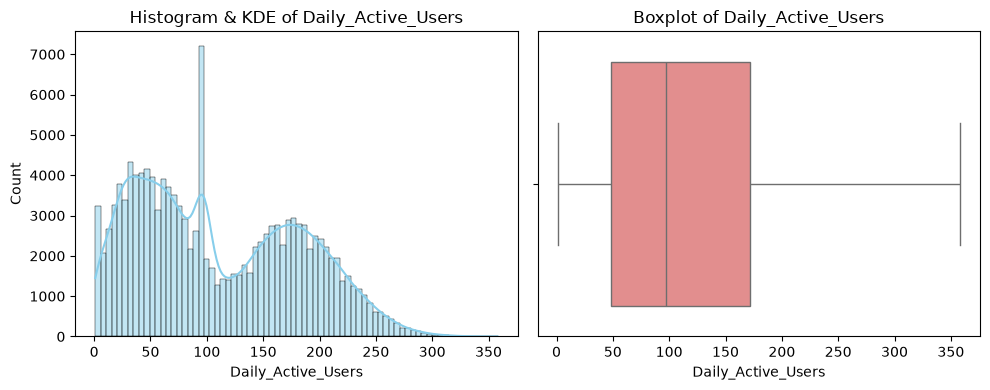

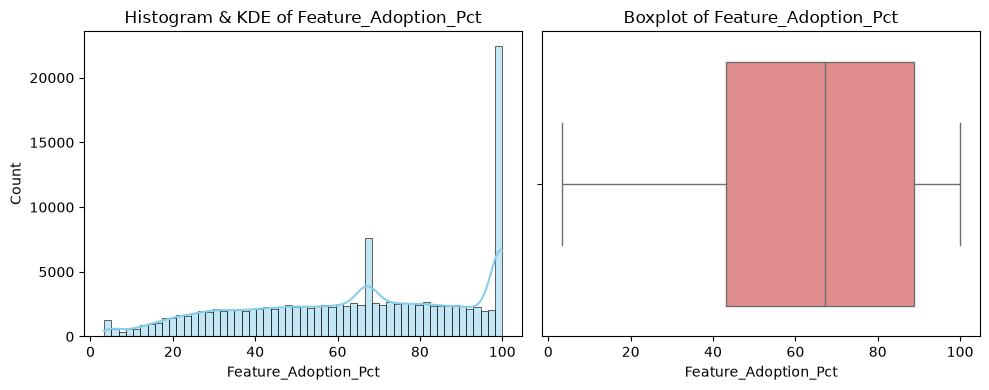

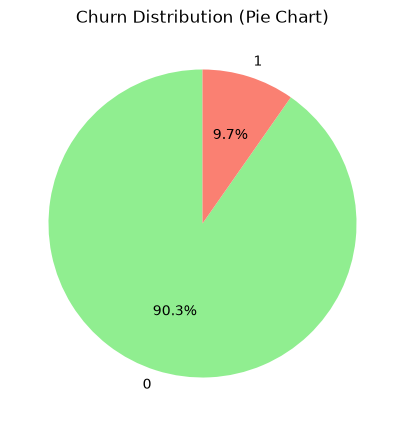

C:\Users\shenbagam\AppData\Local\Temp\ipykernel_2564\3447041754.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


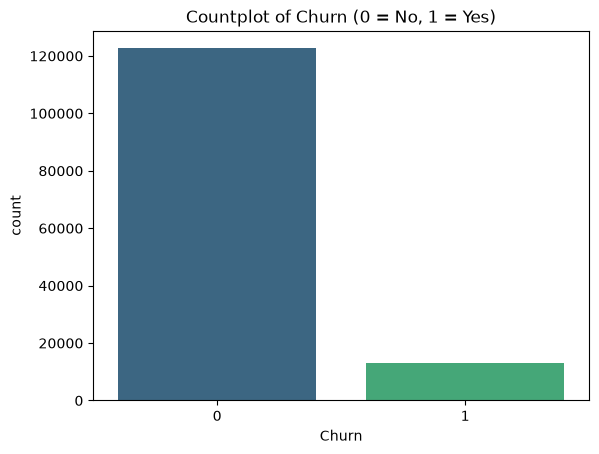

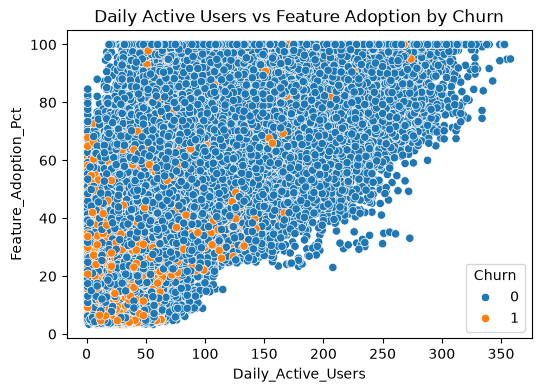

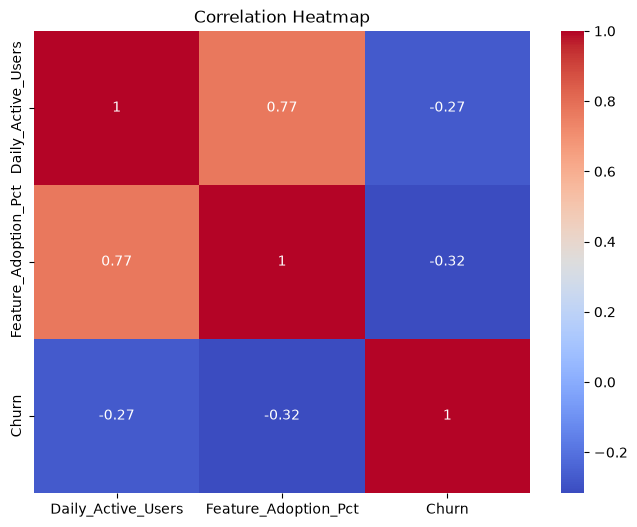

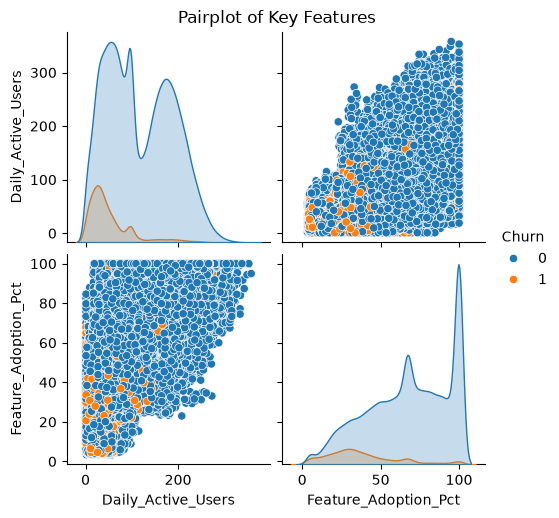


✅ EDA complete — plots generated successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/cleaned_churn.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns)
print("Data types:\n", df.dtypes)
print("Summary:\n", df.describe())

df['Churn'] = df['Churn'].astype(int)

numeric_cols = ['Daily_Active_Users', 'Feature_Adoption_Pct']

for col in numeric_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Histogram & KDE of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['lightgreen','salmon'], startangle=90)
plt.title("Churn Distribution (Pie Chart)")
plt.ylabel('')
plt.show()

sns.countplot(x='Churn', data=df, palette='viridis')
plt.title("Countplot of Churn (0 = No, 1 = Yes)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='Daily_Active_Users', y='Feature_Adoption_Pct', hue='Churn', data=df)
plt.title("Daily Active Users vs Feature Adoption by Churn")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols + ['Churn']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[numeric_cols + ['Churn']], hue='Churn')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

print("\n✅ EDA complete — plots generated successfully.")


In [ ]:

df['Churn'] = np.where((df['Daily_Active_Users'] < 20) | 
                       (df['Feature_Adoption_Pct'] < 30), 1, 0)

print(df['Churn'].value_counts())


Churn
0    107636
1     23152
Name: count, dtype: int64


In [ ]:

import pandas as pd
import numpy as np

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/cleaned_churn.csv"
df = pd.read_csv(file_path)

df['Activity_Ratio'] = df['Daily_Active_Users'] / df['Daily_Active_Users'].max()

df['Feature_Adoption_Level'] = pd.cut(df['Feature_Adoption_Pct'],
                                      bins=[0, 25, 50, 75, 100],
                                      labels=['Low', 'Medium', 'High', 'Very High'])

df['Engagement_Score'] = (0.6 * df['Feature_Adoption_Pct']) + (0.4 * df['Daily_Active_Users'])
df['Low_Adoption_Flag'] = np.where(df['Feature_Adoption_Pct'] < 30, 1, 0)
df['Adoption_x_Activity'] = df['Feature_Adoption_Pct'] * df['Daily_Active_Users']
output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/feature_engineered_churn.csv"
df.to_csv(output_path, index=False)

print("\n✅ Feature Engineering complete. File saved at:", output_path)
print(df.head())



✅ Feature Engineering complete. File saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/feature_engineered_churn.csv
   Customer_Id  Daily_Active_Users  Feature_Adoption_Pct  Churn  \
0      11177.0                13.0                  38.1      0   
1      14771.0                25.0                  45.5      0   
2      11091.0               150.0                  66.5      0   
3      14818.0                38.0                   5.0      1   
4      14376.0               149.0                  70.7      0   

   Activity_Ratio Feature_Adoption_Level  Engagement_Score  Low_Adoption_Flag  \
0        0.036313                 Medium             28.06                  0   
1        0.069832                 Medium             37.30                  0   
2        0.418994                   High             99.90                  0   
3        0.106145                    Low             18.20                  1   
4        0.416201                   High            102.02       

In [ ]:

import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/feature_engineered_churn.csv"
df = pd.read_csv(file_path)

customer_ids = df["Customer_Id"]  
y = df["Churn"].astype(int)      
X = df.drop(columns=["Churn", "Customer_Id"])  

numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

if categorical_cols:
    onehot = OneHotEncoder(drop="first", sparse_output=False)
    encoded = onehot.fit_transform(X[categorical_cols])
    encoded_df = pd.DataFrame(encoded, columns=onehot.get_feature_names_out(categorical_cols))
    X = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)


scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

final_df = pd.concat([customer_ids, X, y], axis=1)

output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn.csv"
final_df.to_csv(output_path, index=False)

print("\n✅ Encoding + Scaling complete. File saved at:", output_path)
print(final_df.head())


C:\Users\shenbagam\AppData\Local\Temp\ipykernel_1636\1122034043.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


Numeric Columns: ['Daily_Active_Users', 'Feature_Adoption_Pct', 'Activity_Ratio', 'Engagement_Score', 'Low_Adoption_Flag', 'Adoption_x_Activity']
Categorical Columns: ['Feature_Adoption_Level']

✅ Encoding + Scaling complete. File saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn.csv
   Customer_Id  Daily_Active_Users  Feature_Adoption_Pct  Activity_Ratio  \
0      11177.0           -1.357137             -0.978254       -1.357137   
1      14771.0           -1.190165             -0.704506       -1.190165   
2      11091.0            0.549128              0.072346        0.549128   
3      14818.0           -1.009278             -2.202721       -1.009278   
4      14376.0            0.535213              0.227717        0.535213   

   Engagement_Score  Low_Adoption_Flag  Adoption_x_Activity  \
0         -1.290187          -0.395066            -1.100014   
1         -1.072964          -0.395066            -1.013218   
2          0.398697          -0.395066

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn_clean.csv"
df = pd.read_csv(file_path)

customer_ids = df["Customer_Id"]
X = df.drop(columns=["Churn", "Customer_Id"])
y = df["Churn"]

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

new_ids = list(customer_ids) + list(
    range(customer_ids.max() + 1, customer_ids.max() + 1 + (len(X_res) - len(X)))
)
synthetic_flags = [0] * len(customer_ids) + [1] * (len(X_res) - len(X))

smote_df = pd.concat([
    pd.Series(new_ids, name="Customer_Id"),
    pd.DataFrame(X_res, columns=X.columns),
    pd.Series(y_res, name="Churn"),
    pd.Series(synthetic_flags, name="Synthetic")
], axis=1)

output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/smote_churn.csv"
smote_df.to_csv(output_path, index=False)

print("✅ SMOTE-balanced dataset saved with Customer_Id + Synthetic flag")
print("Shape after SMOTE:", smote_df.shape)


✅ SMOTE-balanced dataset saved with Customer_Id + Synthetic flag
Shape after SMOTE: (245188, 12)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_path = r"C:\Users\shenbagam\Downloads\FINALPROJECT\Cleaned"
transactions_file = os.path.join(cleaned_path, "fact_transactions_cleaned.csv")
df = pd.read_csv(transactions_file)

print("✅ Dataset Shape:", df.shape)
print("✅ Column Names:", df.columns.tolist())
print("✅ Missing Values:\n", df.isnull().sum())
print("✅ Data Types:\n", df.dtypes)

print("📊 Summary Stats:\n", df.describe(include="all"))

plt.figure(figsize=(8,5))
sns.histplot(df["revenue_usd"], bins=50, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="fiscal_quarter", y="revenue_usd", data=df)
plt.title("Revenue by Fiscal Quarter")
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(x="fiscal_year", y="revenue_usd", data=df, estimator="sum")
plt.title("Total Revenue per Year")
plt.show()

if "customer_segment" in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x="customer_segment", y="revenue_usd", data=df, estimator="sum")
    plt.title("Revenue by Customer Segment")
    plt.xticks(rotation=45)
    plt.show()

if "region" in df.columns:
    plt.figure(figsize=(10,6))
    sns.barplot(x="region", y="revenue_usd", data=df, estimator="sum")
    plt.title("Revenue by Region")
    plt.xticks(rotation=45)
    plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


✅ Dataset Shape: (54463, 29)
✅ Column Names: ['transaction_id', 'customer_id', 'product_id', 'geo_id', 'transaction_date', 'fiscal_quarter', 'transaction_type', 'plan_type', 'currency', 'fx_rate_to_usd', 'transaction_amount_local', 'discount_pct', 'net_revenue_local', 'net_revenue_usd', 'tax_rate_pct', 'tax_amount_usd', 'add_on_revenue_usd', 'total_billed_usd', 'payment_method', 'payment_status', 'payment_delay_days', 'invoice_number', 'po_number', 'billing_cycle', 'auto_renewal', 'sales_rep_id', 'deal_source', 'opportunity_id', 'churn']
✅ Missing Values:
 transaction_id              0
customer_id                 0
product_id                  0
geo_id                      0
transaction_date            0
fiscal_quarter              0
transaction_type            0
plan_type                   0
currency                    0
fx_rate_to_usd              0
transaction_amount_local    0
discount_pct                0
net_revenue_local           0
net_revenue_usd             0
tax_rate_pct     

KeyError: 'revenue_usd'

<Figure size 800x500 with 0 Axes>

In [ ]:
import os
import pandas as pd

cleaned_path = r"C:\Users\shenbagam\Downloads\FINALPROJECT\Cleaned"
transactions_file = os.path.join(cleaned_path, "fact_transactions_cleaned.csv")

df = pd.read_csv(transactions_file)

df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["fiscal_year"] = df["transaction_date"].dt.year
df["fiscal_quarter"] = df["transaction_date"].dt.quarter

df["month"] = df["transaction_date"].dt.month

if "revenue_usd" not in df.columns and {"quantity", "unit_price"}.issubset(df.columns):
    df["revenue_usd"] = df["quantity"] * df["unit_price"]

df = df.sort_values(by=["customer_id", "transaction_date"])
df["prev_revenue_usd"] = df.groupby("customer_id")["revenue_usd"].shift(1)

df["revenue_growth_usd"] = df["revenue_usd"] - df["prev_revenue_usd"]

df["quarterly_avg_revenue_usd"] = df.groupby("customer_id")["revenue_usd"].transform(lambda x: x.rolling(3, min_periods=1).mean())

if "customer_since" in df.columns:
    df["customer_since"] = pd.to_datetime(df["customer_since"], errors="coerce")
    df["tenure_months"] = ((df["transaction_date"] - df["customer_since"]).dt.days / 30).astype(int)

df["customer_lifetime_value_usd"] = df.groupby("customer_id")["revenue_usd"].cumsum()

output_file = os.path.join(cleaned_path, "fact_transactions_feature_engineered.csv")
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"✅ Feature engineered dataset saved at {output_file} with shape {df.shape}")


KeyError: 'Column not found: revenue_usd'

In [ ]:
import pandas as pd

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/smote_churn.csv"

good_rows = []
bad_rows = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        try:
            
            row = pd.read_csv(pd.compat.StringIO(line), sep=",")
            good_rows.append(line)
        except Exception:
            bad_rows.append((i+1, line.strip()))

print("✅ Good rows:", len(good_rows))
print("❌ Bad rows:", len(bad_rows))

with open("bad_rows.csv", "w", encoding="utf-8") as out:
    out.write("Line_Number,Content\n")
    for num, content in bad_rows:
        out.write(f"{num},{content}\n")

print("📂 Bad rows saved to bad_rows.csv")


✅ Good rows: 0
❌ Bad rows: 245189
📂 Bad rows saved to bad_rows.csv


In [ ]:
import pandas as pd

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn.csv"

df = pd.read_csv(file_path, sep=",", engine="c", low_memory=False)

df_clean = df.dropna(subset=["Customer_Id", "Churn"])

df_clean["Customer_Id"] = df_clean["Customer_Id"].astype(int)

output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn_clean.csv"
df_clean.to_csv(output_path, index=False)

print("✅ Clean dataset saved at:", output_path)
print("Shape after cleaning:", df_clean.shape)


✅ Clean dataset saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn_clean.csv
Shape after cleaning: (135787, 11)


In [ ]:

import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE

file_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/encoded_scaled_churn_clean.csv"
df = pd.read_csv(file_path)

customer_ids = df["Customer_Id"]   
X = df.drop(columns=["Churn", "Customer_Id"])
y = df["Churn"]

print("Original Churn Distribution:", Counter(y))

smote_done = False
minority_ratio = y.value_counts(normalize=True).min()

if minority_ratio < 0.4:   
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    print("Resampled Churn Distribution:", Counter(y_res))
    smote_done = True
    
    new_ids = range(1, len(X_res) + 1)
    smote_df = pd.concat([pd.Series(new_ids, name="Customer_Id"), X_res, y_res], axis=1)


    output_path = r"C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/smote_churn.csv"
    smote_df.to_csv(output_path, index=False)
    print("\n📂 SMOTE-balanced dataset saved at:", output_path)
else:
    print("Dataset is balanced enough, SMOTE not applied.")

if smote_done:
    print("\n✅ SMOTE has been applied and file saved.")
else:
    print("\nℹ️ SMOTE was not applied because the dataset is already balanced.")


Original Churn Distribution: Counter({0: 122594, 1: 13193})
Resampled Churn Distribution: Counter({0: 122594, 1: 122594})

📂 SMOTE-balanced dataset saved at: C:/Users/shenbagam/Downloads/FINALPROJECT/Outputs/smote_churn.csv

✅ SMOTE has been applied and file saved.
